# Does the pre-fit trajectory repeat?

Local investigation, 5 October 2026. No repository changes or background/interference fits.

**Result:** the broad two-pass curve repeats, and averaging substantially reduces jitter.
The precise curve is not invariant across chronological intervals. Preserve that variability
instead of treating one smooth average as known ground truth.

- 30–31 s: 304 complete *detected traversals*, each with one clockwise outer-loop winding.
  A data-specific outer-loop crossing defines boundaries; this does not independently measure mechanical phase.
- Even/odd averages (152 cycles each) differ by about **0.008 geometric RMS** in raw X/Y.
- Eight consecutive 38-cycle averages differ from the full mean by **0.013–0.039**;
  eight interleaved groups of the same size differ by **0.009–0.017**. Chronological
  differences exceed those obtained by mixing cycles across the second. This is
  evidence of time-correlated variation, not a formal separation of detector noise,
  preprocessing error, background drift and rod motion.
- Constrained time alignment changes the overall mean by **0.026 geometric RMS**.
  It reduces registration error but must not be accepted just because curves agree better.
- Guide windows 21–81 samples change the unwarped mean by up to **0.015 geometric RMS**
  relative to the 41-sample default. Fine features smaller than this are not yet robust.
- Separated windows at 0, 10, 20, 30 and 39 s retain the broad two-pass structure.
  10–11 s is more consistent across its four subintervals than 30–31 s.

**Correction to the previous interpretation:** the selected first cycle reaching Y≈0.54
was not proof that the ensemble trajectory should reach that height. The 304-cycle
mean reaches Y≈0.39 without the old 201-sample periodic filter. That earlier single-cycle
comparison overstated the evidence for bias in the ensemble reference. The old filter
still demonstrably changes individual traces; neither old nor new reference is ground truth.

## What is averaged

The four original channel voltages are averaged within contiguous bins on each
observed cycle, then corresponding bins are averaged with **equal weight per cycle**.
X/Y are calculated afterwards. Cycles are not weighted by how long they take.
A light channel smoother sets bin boundaries only. Both repeated passes remain in
acquisition order. No cone or optical anisotropy template is imposed.

The optional alignment uses a reference from even cycles only, with monotone mappings,
fixed endpoints, a ±12-bin band and a step penalty. Some source bins are reused under
that mapping (about 22% of mapping steps repeat an index); those outputs are correlated.
It is a sensitivity diagnostic, not the default recommended final reference. The
unwarped and chronological-group comparisons are essential controls.

All comparisons use the same calibration. The archived gain estimates are held fixed;
T keeps the current numerical coefficients and /8 scale. Fresnel and pupil inversion
are not needed for this empirical repeatability test. No angle inference is performed.

## Interpretation and next step

Use a **time window containing several complete traversals**, review a single ordered
cycle as a branch-order reference, and check agreement across subwindows. This dataset
allows automatic boundaries using an isolated outer-loop crossing, avoiding hundreds
of manual cycle selections. The gate is dataset-specific and must be visually reviewed
on another sample. There is no universal one-track/two-track switch or assumed speed.

The old single-cycle binning is useful diagnostically but too noisy to promote directly
as the final fit reference. A candidate final fit should use multiple chronological
averages, retain between-window scatter, and demonstrate consistent conclusions across
registration choices. Do not infer that a good fit to the grand average fits every cycle.

## Run

Requires numpy, scipy, matplotlib, npTDMS and IPython. Put this notebook beside
`files3_first40s.tdms`, or edit `TDMS_PATH`. Saved outputs and plots are embedded below;
rerunning reads the raw data. The final cell also checks four other one-second windows.
The current numerical summary applies only to the supplied sample and settings.


In [1]:
from pathlib import Path
TDMS_PATH = Path("files3_first40s.tdms")
OUT = Path("trajectory_repeatability_outputs")
OUT.mkdir(exist_ok=True)
WINDOW_START, WINDOW_END = 30.0, 31.0
N_PHASE_BINS = 128
GAIN_STACK_90_45_135_0 = [1.00826325584303, 1.2803656485620056, 1.091743363827011, 1.0]


{
  "n_cycles": 304,
  "gate": {
    "x": -0.5,
    "y_below": -0.3,
    "rearm_x": 0.3
  },
  "time_range_s": [
    30.000472,
    30.9999
  ],
  "duration_ms_quantiles": [
    2.376,
    2.895,
    3.174,
    3.4979999999999998,
    10.2
  ],
  "raw_coordinate_results": {
    "single_to_mean_ordered_rms_median": 0.16088783922275385,
    "single_to_mean_normal_rms_median": 0.08175090013149842,
    "even_odd_mean_rms": 0.015372133523203345,
    "even_odd_mean_geometric_rms": 0.00790101440466353,
    "aligned_even_odd_mean_rms": 0.009735137162343832,
    "unwarped_vs_aligned_mean_rms": 0.02846865734504503,
    "unwarped_vs_aligned_mean_geometric_rms": 0.026317258670472035
  },
  "group_intervals_s": [
    [
      30.000472,
      30.119115999999998
    ],
    [
      30.119115999999998,
      30.242704
    ],
    [
      30.242704,
      30.377756
    ],
    [
      30.377756,
      30.501816
    ],
    [
      30.501816,
      30.626304
    ],
    [
      30.626304,
      30.747356
   

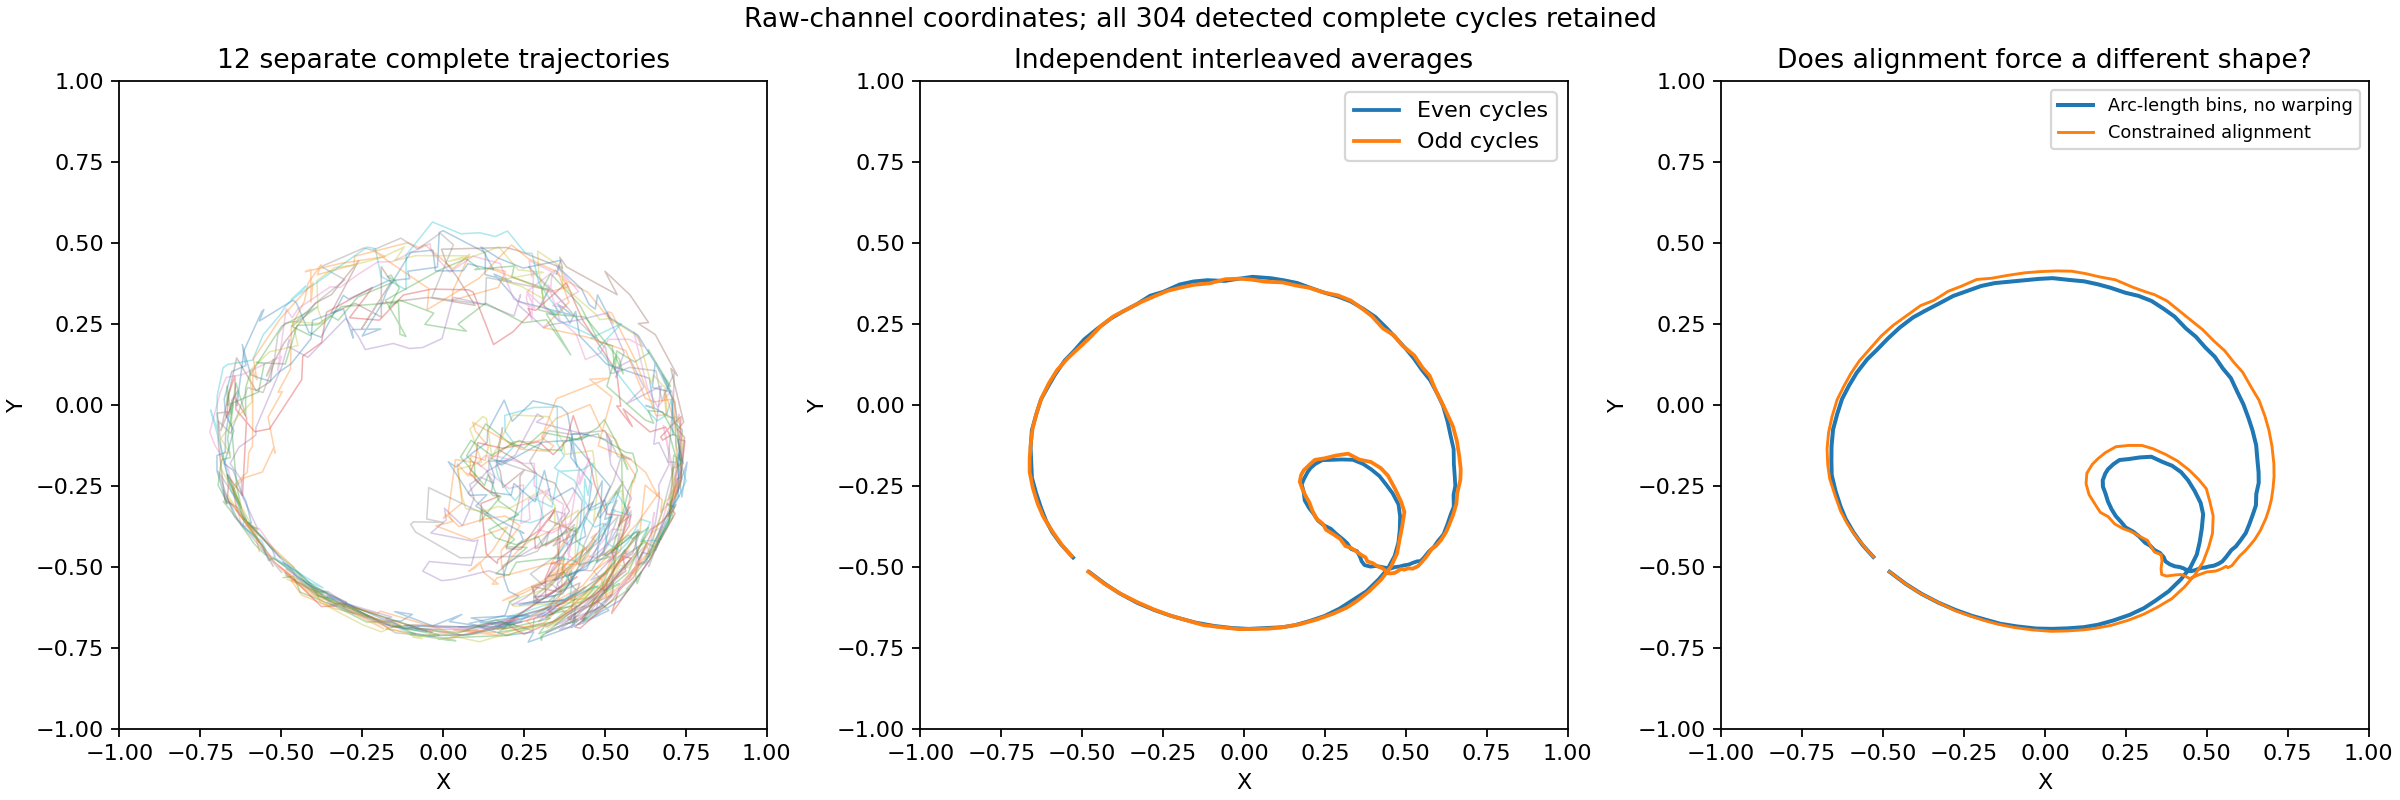

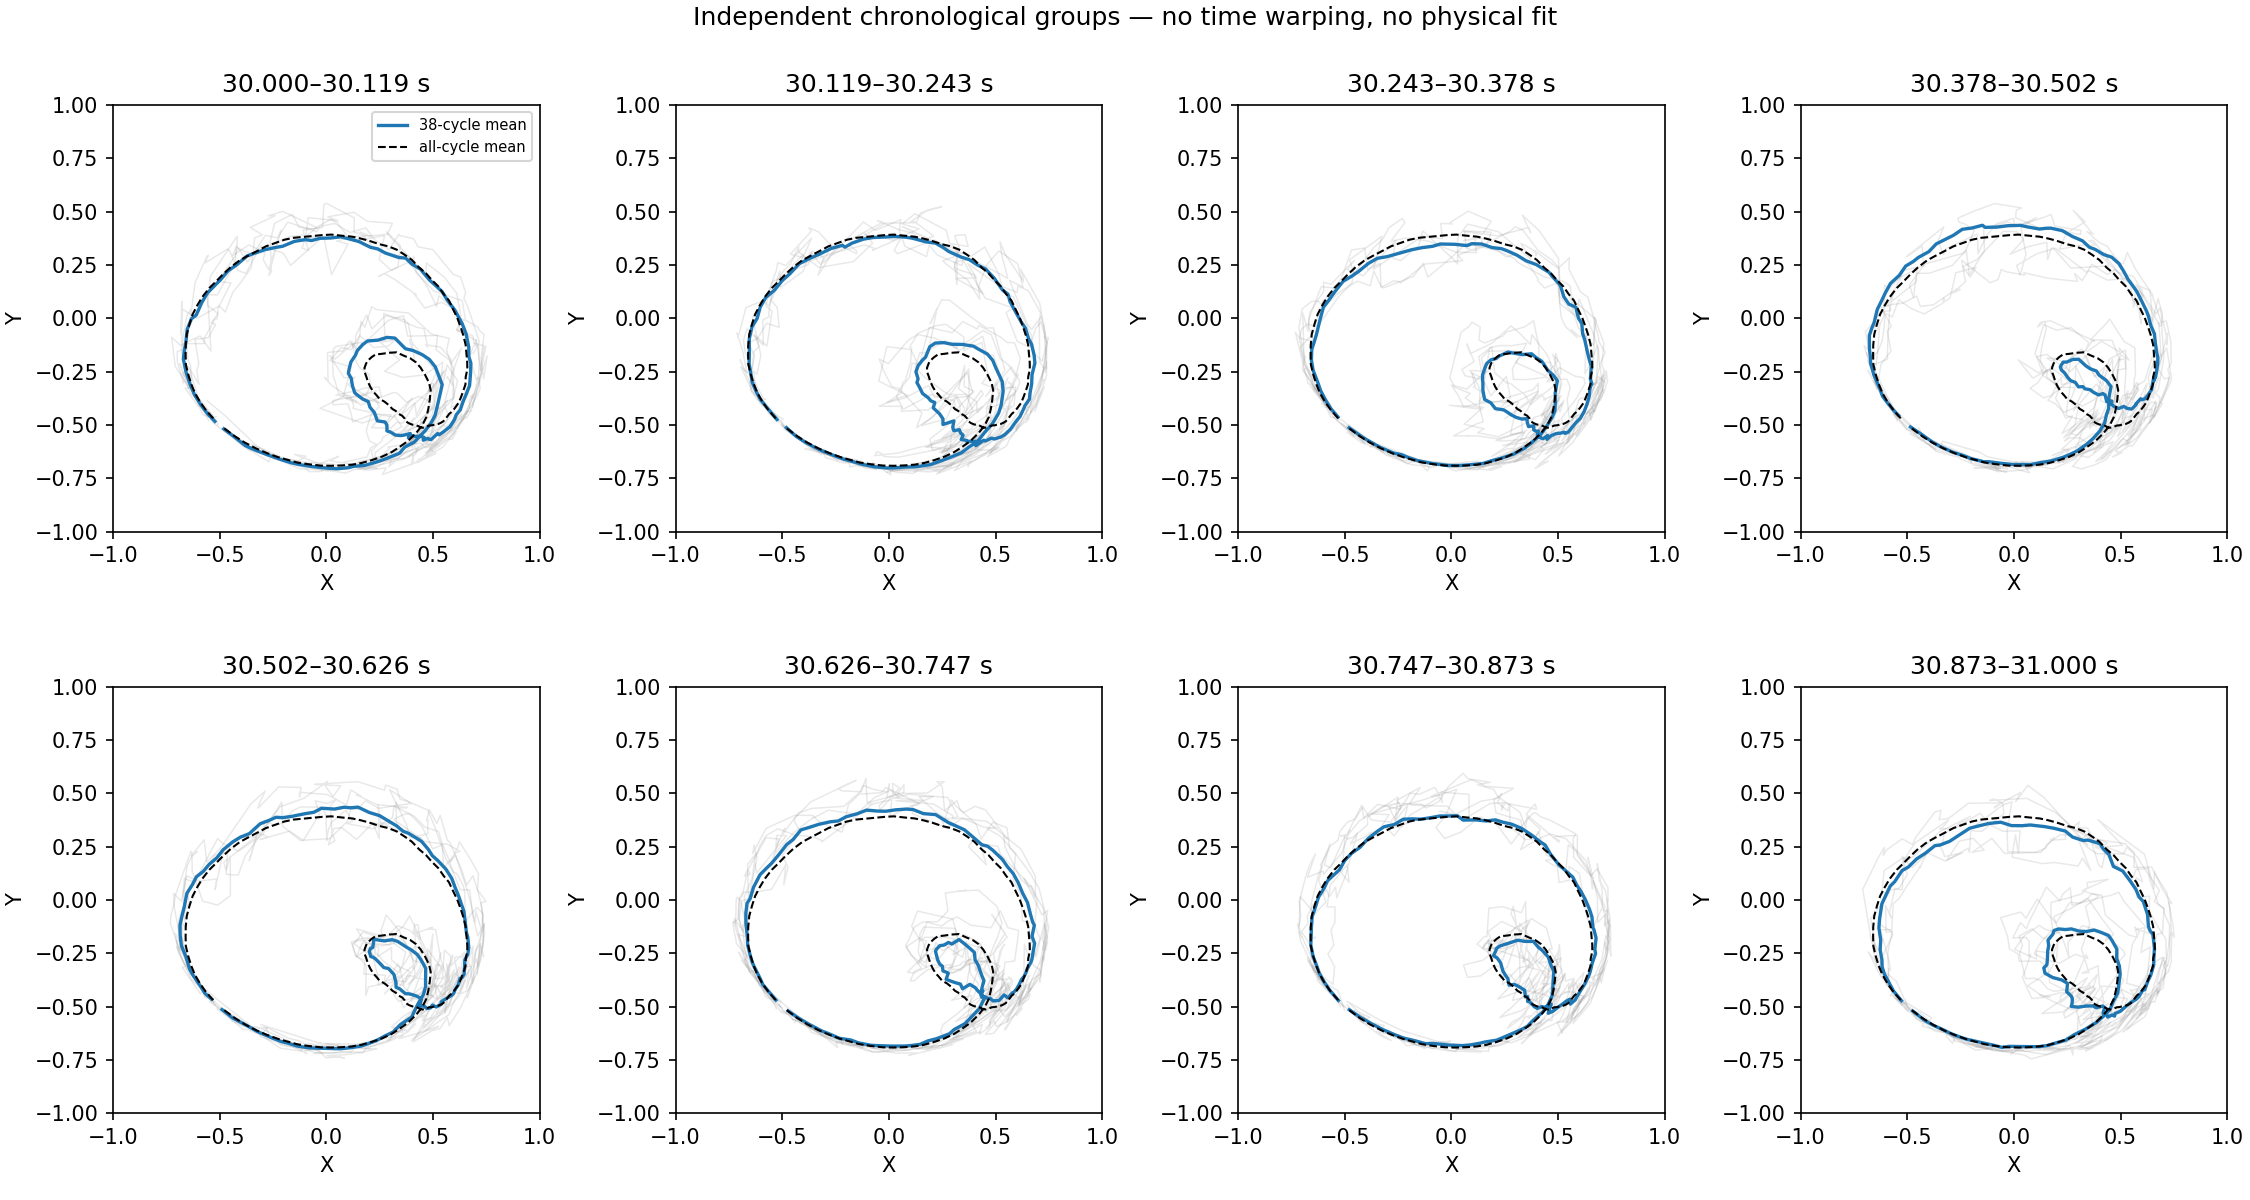

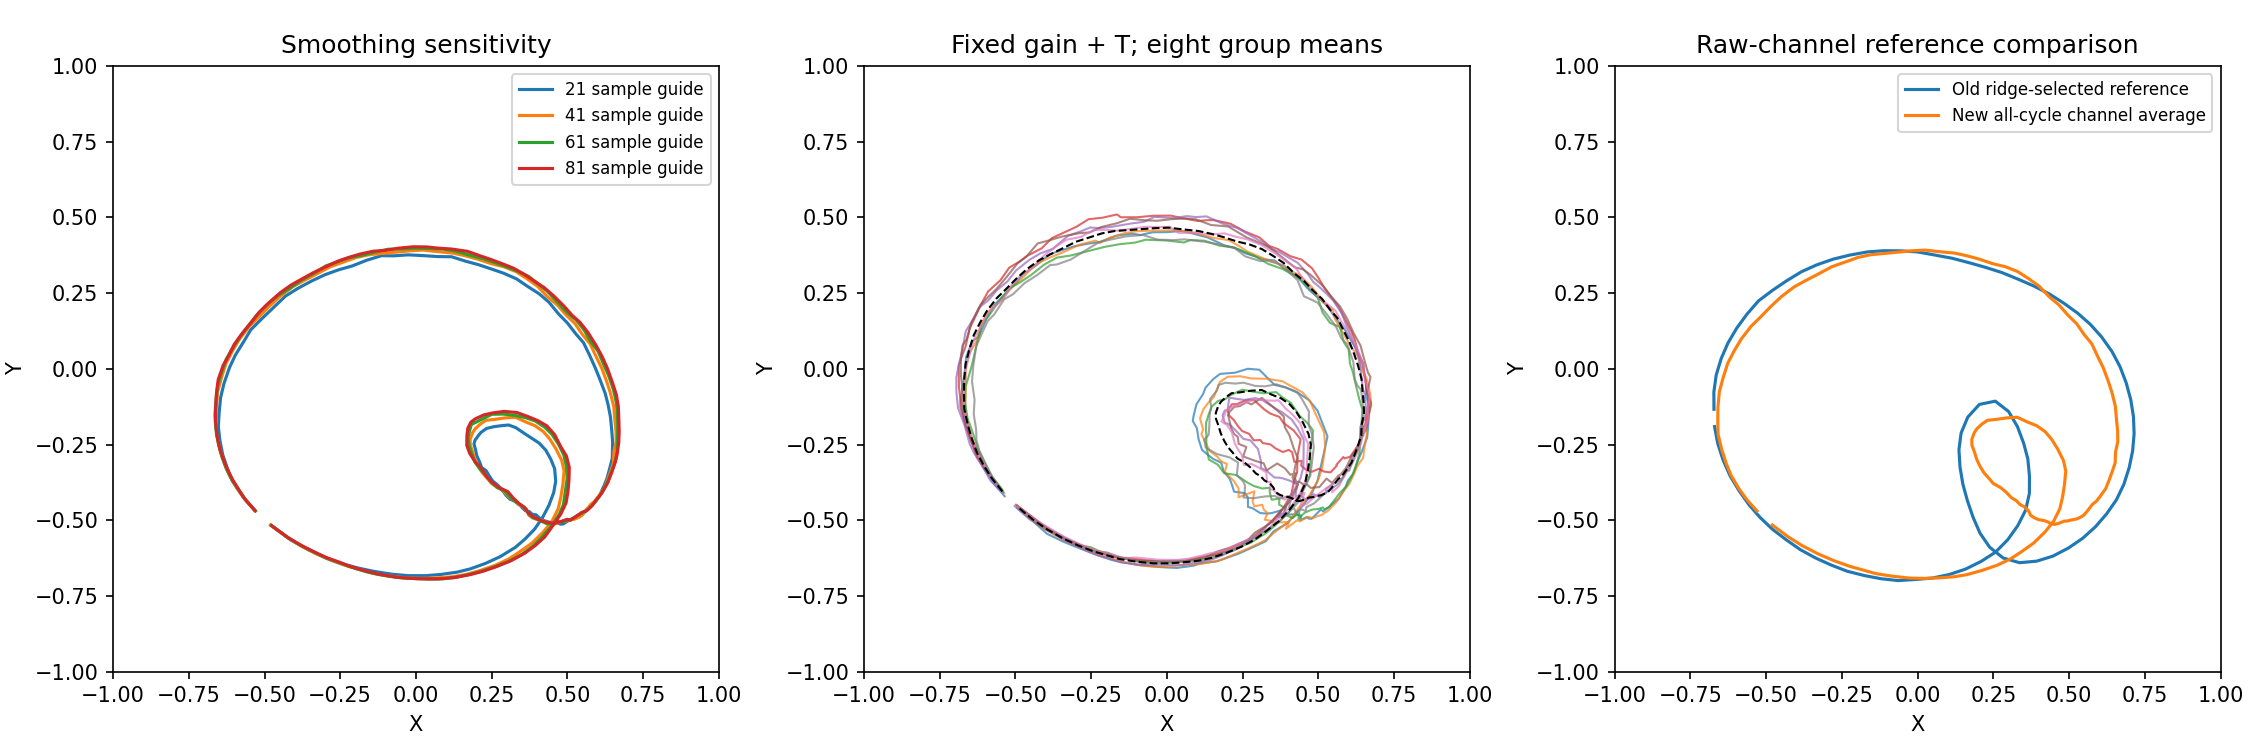

In [2]:
from pathlib import Path
import json
import numpy as np
from scipy.signal import savgol_filter
from scipy.spatial import cKDTree
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
ROOT=OUT
from nptdms import TdmsFile
with TdmsFile.open(TDMS_PATH) as f:
    channels_tdms=f.groups()[0].channels()
    DT=float(channels_tdms[0].properties['wf_increment'])
    offset=float(channels_tdms[0].properties.get('wf_start_offset',0))
    lo=round((WINDOW_START-offset)/DT);hi=round((WINDOW_END-offset)/DT)
    raw=np.array([ch[lo:hi] for ch in channels_tdms],float)[[3,0,1,2]]
N=N_PHASE_BINS

def xy(c):
 return np.stack([(c[...,0,:]-c[...,1,:])/(c[...,0,:]+c[...,1,:]),(c[...,2,:]-c[...,3,:])/(c[...,2,:]+c[...,3,:])],axis=-1)
def guide(c,w):return xy(savgol_filter(c,w,3,axis=-1))
def anchors(p,threshold=-.5):
 x,y=p.T;out=[];armed=False
 for i in range(1,len(x)):
  if x[i]>.3:armed=True
  if armed and x[i]<threshold<=x[i-1] and y[i]<-.3:out.append(i);armed=False
 return np.array(out)
def bin_cycles(raw,g,bounds):
 vals=[];gs=[];counts=[]
 for a,b in zip(bounds[:-1],bounds[1:]):
  pp=g[a:b]
  if len(pp)<N:raise ValueError('A detected interval has fewer samples than phase bins; review the gate.')
  ss=np.r_[0.,np.cumsum(np.linalg.norm(np.diff(pp,axis=0),axis=1))]
  edges=np.r_[0,np.searchsorted(ss,np.linspace(0,ss[-1],N+1)[1:-1]),len(pp)]
  for k in range(1,N):edges[k]=np.clip(edges[k],edges[k-1]+1,len(pp)-(N-k))
  centers=(edges[:-1]+edges[1:]-1)/2
  vals.append(np.column_stack([raw[:,a+i:a+j].mean(axis=1) for i,j in zip(edges[:-1],edges[1:])]))
  gs.append(np.column_stack([np.interp(centers,np.arange(len(pp)),pp[:,j]) for j in range(2)]))
  counts.append(np.diff(edges))
 return np.array(vals),np.array(gs),np.array(counts)
def align_path(ref,p,band=12,penalty=.0005):
 # Monotone point correspondence; steps 0,1,2, fixed endpoints. Band prevents
 # large phase shifts/branch changes. Unwarped averages remain the control.
 n=len(ref);D=np.full((n,n),np.inf);back=np.full((n,n),-1,dtype=int)
 D[0,0]=np.sum((ref[0]-p[0])**2)
 for i in range(1,n):
  js=np.arange(max(0,i-band),min(n,i+band+1))
  for step in (1,0,2):
   prev=js-step;valid=prev>=0;j=js[valid];v=prev[valid]
   cost=D[i-1,v]+np.sum((p[j]-ref[i])**2,axis=1)+penalty*(step!=1)
   improve=cost<D[i,j];D[i,j[improve]]=cost[improve];back[i,j[improve]]=v[improve]
 j=n-1;path=[j]
 for i in range(n-1,0,-1):j=back[i,j];path.append(j)
 return np.array(path[::-1])
def rms(a,b):return float(np.sqrt(np.mean(np.sum((a-b)**2,axis=-1))))
def geom(a,b):
 # Symmetric nearest-curve distance ignores timing; complement, not replace,
 # the ordered metric. Dense interpolation avoids coarse-grid artefacts.
 def dense(p):
  t=np.arange(len(p));u=np.linspace(0,len(p),4096,endpoint=False)
  return np.column_stack([np.interp(u,np.r_[t,len(p)],np.r_[p[:,j],p[0,j]]) for j in range(2)])
 a,b=dense(a),dense(b)
 return float(np.sqrt((np.mean(cKDTree(a).query(b)[0]**2)+np.mean(cKDTree(b).query(a)[0]**2))/2))
def normal_rms(p,ref):
 t=np.roll(ref,-1,axis=0)-np.roll(ref,1,axis=0);v=np.linalg.norm(t,axis=1)
 n=np.column_stack([-t[:,1],t[:,0]])/np.maximum(v[:,None],1e-10)
 return float(np.sqrt(np.mean(np.sum((p-ref)*n,axis=-1)**2)))
def axxy(ax):ax.set(xlim=(-1,1),ylim=(-1,1),aspect='equal',xlabel='X',ylabel='Y')

baseguide=guide(raw,41);bounds=anchors(baseguide)
channels,guides,counts=bin_cycles(raw,baseguide,bounds)
k=len(channels);train=np.arange(k)%2==0
# Reference from even cycles only, never an optical/cone template.
ref=xy(channels[train].mean(axis=0))
paths=np.array([align_path(ref,g) for g in guides])
aligned=np.array([c[:,p] for c,p in zip(channels,paths)])
p=xy(channels);pa=xy(aligned)
mean=xy(channels.mean(axis=0));ma=xy(aligned.mean(axis=0))
groups=np.array_split(np.arange(k),8)
unwarped_groups=np.array([xy(channels[g].mean(axis=0)) for g in groups])
aligned_groups=np.array([xy(aligned[g].mean(axis=0)) for g in groups])
metrics=dict(n_cycles=k,gate=dict(x=-.5,y_below=-.3,rearm_x=.3),
 time_range_s=(WINDOW_START+bounds[[0,-1]]*DT).tolist(),duration_ms_quantiles=np.percentile(np.diff(bounds)*DT*1000,[0,25,50,75,100]).tolist(),
 raw_coordinate_results=dict(single_to_mean_ordered_rms_median=float(np.median([rms(a,mean) for a in p])),
 single_to_mean_normal_rms_median=float(np.median([normal_rms(a,mean) for a in p])),
 even_odd_mean_rms=rms(xy(channels[train].mean(axis=0)),xy(channels[~train].mean(axis=0))),
 even_odd_mean_geometric_rms=geom(xy(channels[train].mean(axis=0)),xy(channels[~train].mean(axis=0))),
 aligned_even_odd_mean_rms=rms(xy(aligned[train].mean(axis=0)),xy(aligned[~train].mean(axis=0))),
 unwarped_vs_aligned_mean_rms=rms(mean,ma),unwarped_vs_aligned_mean_geometric_rms=geom(mean,ma)),
 group_intervals_s=[[float(WINDOW_START+bounds[g[0]]*DT),float(WINDOW_START+bounds[g[-1]+1]*DT)] for g in groups],
 group_to_mean_rms=[rms(g,mean) for g in unwarped_groups],
 group_to_mean_geometric_rms=[geom(g,mean) for g in unwarped_groups],
 aligned_group_to_mean_rms=[rms(g,ma) for g in aligned_groups],
 alignment=dict(max_band_bins=12,step_penalty=.0005,
  band_touch_fraction=float(np.mean(np.abs(paths-np.arange(N))==12)),
  median_rms_shift_bins=float(np.median(np.sqrt(np.mean((paths-np.arange(N))**2,axis=1)))),
  fraction_repeated_source_bins=float(np.mean(np.diff(paths,axis=1)==0))))

# Change guide smoothing while keeping exactly the same interval boundaries.
variants={};sens={}
for w in (21,41,61,81):
 c,g,ct=bin_cycles(raw,guide(raw,w),bounds);m=xy(c.mean(axis=0));variants[w]=m
 sens[w]=dict(mean_geometric_rms=geom(m,mean),mean_ordered_rms=rms(m,mean),max_y=float(m[:,1].max()),
             independently_detected_crossings=len(anchors(guide(raw,w))))
metrics['smoothing_sensitivity']=sens
# Alternate seed templates from nonoverlapping chronological quarters.
seed_sensitivity=[]
for inds in [np.arange(0,k//4),np.arange(3*k//4,k)]:
 rr=xy(channels[inds].mean(axis=0));pp=np.array([align_path(rr,g) for g in guides])
 aa=np.array([c[:,q] for c,q in zip(channels,pp)]);mm=xy(aa.mean(axis=0))
 seed_sensitivity.append(dict(geometric_rms_to_base=geom(mm,ma),ordered_rms_to_base=rms(mm,ma)))
metrics['alignment_seed_sensitivity']=seed_sensitivity

# Fixed historical gain and T; never re-estimate per interval.
def T_Icor_Matrix():  # order: 0, 90, 45, 135, with 45 reflected
    ret = np.zeros([4, 4])
    ret[0][0] = 0.152  # transmitted
    ret[0][1] = 0
    ret[1][0] = 0
    ret[1][1] = 0.148  # reflected
    alpha = 0.455
    beta  = 0.009  # This is quite critical
    t     = 0.757  # transmitted in PBS
    r     = 0.741  # reflected
    ret[2][0] = -alpha * beta * r  # Reflected
    ret[2][1] =  alpha * beta * r
    ret[2][2] =  alpha * alpha * r
    ret[2][3] =  beta  * beta  * r
    ret[3][0] = -alpha * beta * t  # Transmitted
    ret[3][1] =  alpha * beta * t
    ret[3][2] =  beta  * beta  * t
    ret[3][3] =  alpha * alpha * t
    return np.linalg.inv(ret) / 8


ns={'T_Icor_Matrix':T_Icor_Matrix}
a=np.asarray(GAIN_STACK_90_45_135_0)[[3,0,1,2]]
cal=ns['T_Icor_Matrix']()@np.diag(a)
cc=np.einsum('ij,kjl->kil',cal,channels);ac=np.einsum('ij,kjl->kil',cal,aligned)
cm=xy(cc.mean(axis=0));am=xy(ac.mean(axis=0))
metrics['fixed_calibration']=dict(gains_0_90_45_135=a.tolist(),
 even_odd_mean_rms=rms(xy(cc[train].mean(axis=0)),xy(cc[~train].mean(axis=0))),
 even_odd_mean_geometric_rms=geom(xy(cc[train].mean(axis=0)),xy(cc[~train].mean(axis=0))),
 individual_normal_rms_median=float(np.median([normal_rms(q,cm) for q in xy(cc)])),
 group_to_mean_geometric_rms=[geom(xy(cc[g].mean(axis=0)),cm) for g in groups])
# Brightness across intervals is checked separately; it was not used in alignment.
metrics['group_channel_means_0_90_45_135']=[np.mean(channels[g],axis=(0,2)).reshape(-1).tolist() for g in groups]

fig,axs=plt.subplots(2,4,figsize=(15,8),layout='constrained')
for j,(ax,g) in enumerate(zip(axs.ravel(),groups)):
 for idx in g[:5]:ax.plot(p[idx,:,0],p[idx,:,1],alpha=.18,lw=.7,color='grey')
 q=unwarped_groups[j];ax.plot(q[:,0],q[:,1],lw=1.6,color='tab:blue',label=f'{len(g)}-cycle mean')
 ax.plot(mean[:,0],mean[:,1],lw=1,color='black',ls='--',label='all-cycle mean')
 axxy(ax);lo,hi=metrics['group_intervals_s'][j];ax.set_title(f'{lo:.3f}–{hi:.3f} s')
axs[0,0].legend(fontsize=7);fig.suptitle('Independent chronological groups — no time warping, no physical fit')
fig.savefig(ROOT/'interval_groups.png',dpi=150);plt.close(fig)
fig,axs=plt.subplots(1,3,figsize=(15,5),layout='constrained')
for idx in range(0,k,max(1,k//12)):axs[0].plot(p[idx,:,0],p[idx,:,1],alpha=.35,lw=.7)
axs[0].set_title('12 separate complete trajectories')
for mask,label in [(train,'Even cycles'),(~train,'Odd cycles')]:
 q=xy(channels[mask].mean(axis=0));axs[1].plot(q[:,0],q[:,1],label=label,lw=1.7)
axs[1].set_title('Independent interleaved averages');axs[1].legend()
axs[2].plot(mean[:,0],mean[:,1],label='Arc-length bins, no warping',lw=1.8)
axs[2].plot(ma[:,0],ma[:,1],label='Constrained alignment',lw=1.3)
axs[2].set_title('Does alignment force a different shape?');axs[2].legend(fontsize=8)
for ax in axs:axxy(ax)
fig.suptitle(f'Raw-channel coordinates; all {k} detected complete cycles retained')
fig.savefig(ROOT/'repeatability.png',dpi=160);plt.close(fig)
fig,axs=plt.subplots(1,3,figsize=(15,5),layout='constrained')
for w,q in variants.items():axs[0].plot(q[:,0],q[:,1],label=f'{w} sample guide')
axs[0].set_title('Smoothing sensitivity');axs[0].legend(fontsize=8)
for g in groups:
 q=xy(cc[g].mean(axis=0));axs[1].plot(q[:,0],q[:,1],alpha=.7,lw=1)
axs[1].plot(cm[:,0],cm[:,1],'k--',lw=1);axs[1].set_title('Fixed gain + T; eight group means')
# Archived 90-point reference, embedded only for the historical comparison.
qo=np.array([[-0.6723184666420936, -0.13369397217928902], [-0.672663139329806, -0.077217125382263], [-0.665098449207179, -0.021081941129673827], [-0.648367681925953, 0.03406571255795202], [-0.6258940033009353, 0.08555511341026661], [-0.5968908170643529, 0.1346153846153846], [-0.5632096896290689, 0.18058412176059235], [-0.5254736067684385, 0.22409539473684212], [-0.4806070826306914, 0.25794904190355866], [-0.43376027528197286, 0.289760348583878], [-0.3832055358144754, 0.3206122876913399], [-0.3329292929292929, 0.3431254514808572], [-0.2786624203821656, 0.36205698401667824], [-0.2238865588176553, 0.37540603248259863], [-0.16631819045808782, 0.38577442942610235], [-0.11187260632936907, 0.38981341401916286], [-0.05526083112290009, 0.38939670932358317], [0.0006290626965820927, 0.3857003891050584], [0.058109280138768434, 0.37531742001015744], [0.11382113821138211, 0.36495749931450505], [0.16959855660802886, 0.3502178649237473], [0.22322274881516588, 0.33517393705135284], [0.27870216306156403, 0.3174890209248256], [0.33069828722002637, 0.29627630868861304], [0.3828742259235533, 0.2736236647493837], [0.4347370626440394, 0.24708926261319533], [0.482686497792238, 0.2165554072096128], [0.5281966535839703, 0.18369376087496894], [0.5704149645237583, 0.1464559150407508], [0.6078431372549019, 0.10450077599586136], [0.64168966249204, 0.05682951146560319], [0.6682887266828873, 0.006612410986775178], [0.688448310742464, -0.04631043256997455], [0.7035433070866142, -0.10197290230568101], [0.712448132780083, -0.15769414006669843], [0.7146123071061155, -0.21406038756196485], [0.7097470092174937, -0.2709477202196228], [0.698464025869038, -0.32583193679674405], [0.6809532961752834, -0.38092147955872807], [0.6564273136372529, -0.4321305841924399], [0.6240810649711901, -0.47863247863247865], [0.5870893812070282, -0.521383075523203], [0.5447540011855364, -0.5595744680851064], [0.4979253112033195, -0.5915429599640126], [0.44667760459392947, -0.6183307504981183], [0.39284930905900417, -0.6349962396590624], [0.33646812957157785, -0.6400669642857143], [0.2823779193205945, -0.6245733788395904], [0.2377762893503014, -0.5888833249874812], [0.2060778727445394, -0.5428122545168892], [0.18320209973753282, -0.4906689635371806], [0.16444191990911672, -0.4358502148557397], [0.14931064828395424, -0.38080101716465353], [0.13998703823720027, -0.3250728862973761], [0.13634925656437835, -0.2673462676751069], [0.14354936402180496, -0.2119546547578152], [0.16551724137931034, -0.1595900439238653], [0.20384487901889295, -0.11750263065591021], [0.2564102564102564, -0.1068173532628509], [0.3001193317422434, -0.14088215931533904], [0.32929164007657946, -0.19047619047619047], [0.3499554764024933, -0.24552845528455283], [0.3638132295719844, -0.29768885822697483], [0.3692033293697979, -0.3549915397631134], [0.36887100829771186, -0.41150442477876104], [0.35631617828121154, -0.4671689989235737], [0.3304822998336897, -0.5179461615154536], [0.29761644434725565, -0.5640506329113925], [0.25677966101694916, -0.6054832713754646], [0.20990764063811923, -0.6356332703213611], [0.15798390512494706, -0.6612529002320185], [0.1050207277752188, -0.678954248366013], [0.049069373942470386, -0.6907465571394057], [-0.006677140612725845, -0.6954662104362703], [-0.06457925636007827, -0.6991230042725433], [-0.12120626329016045, -0.6929460580912863], [-0.1767328739359546, -0.6822982678495987], [-0.23286052009456265, -0.6681710724263916], [-0.2852220520673813, -0.6479207920792079], [-0.3374834936804377, -0.6242568370986921], [-0.38716356107660455, -0.5970954356846473], [-0.43446737311767986, -0.5640096618357487], [-0.479182156133829, -0.5297361165813312], [-0.5202702702702703, -0.49056228889330417], [-0.5568648455632923, -0.44861273935130913], [-0.5900236664846168, -0.4016631212531425], [-0.6193430656934307, -0.35296442687747037], [-0.6423410404624278, -0.3008098727342846], [-0.6596363636363637, -0.24743083003952568], [-0.6704297159504734, -0.19071183859916255]]);axs[2].plot(qo[:,0],qo[:,1],label='Old ridge-selected reference')
axs[2].plot(mean[:,0],mean[:,1],label='New all-cycle channel average')
axs[2].set_title('Raw-channel reference comparison');axs[2].legend(fontsize=8)
for ax in axs:axxy(ax)
fig.savefig(ROOT/'sensitivity_and_calibration.png',dpi=150);plt.close(fig)
(ROOT/'metrics.json').write_text(json.dumps(metrics,indent=2)+'\n')
np.savez_compressed(ROOT/'averaged_channels.npz',channels_per_cycle=channels,aligned_channels=aligned,
 mean_channels=channels.mean(axis=0),mean_corrected_channels=cc.mean(axis=0),
 interval_bounds=bounds,group_means=np.array([channels[g].mean(axis=0) for g in groups]),
 alignment_paths=paths,counts=counts,calibration=cal)
print(json.dumps(metrics,indent=2))
try:
    from IPython.display import display, Image
except ImportError:
    display = print
    def Image(filename): return filename
for name in ['repeatability.png','interval_groups.png','sensitivity_and_calibration.png']:
    display(Image(filename=str(ROOT/name)))


## Chronological versus interleaved groups, and separated windows

The same group size separates time-local variation from variability after mixing cycles across the whole second.


{
  "chronological_geometric_rms": [
    0.03686202567380675,
    0.03175182998669146,
    0.02456525405438967,
    0.03878283768562084,
    0.02375951039535788,
    0.028049395864182196,
    0.013094436337814642,
    0.024880257356725496
  ],
  "interleaved_geometric_rms": [
    0.016812194834278645,
    0.010464993504992647,
    0.010668157321211935,
    0.008729695477030234,
    0.016148130959473202,
    0.014307351355030003,
    0.013364644804791643,
    0.010677434389545607
  ],
  "outer_loop_winding_counts": {
    "-1": 304
  },
  "separated_windows": [
    {
      "start_s": 0,
      "n_cycles": 241,
      "geometric_rms_to_30s": 0.027966355097312465,
      "quarter_mean_geometric_rms": [
        0.028644923014924523,
        0.009174505830714682,
        0.013626993025031644,
        0.02840972102361917
      ]
    },
    {
      "start_s": 10,
      "n_cycles": 217,
      "geometric_rms_to_30s": 0.04037897529981338,
      "quarter_mean_geometric_rms": [
        0.0099246844903

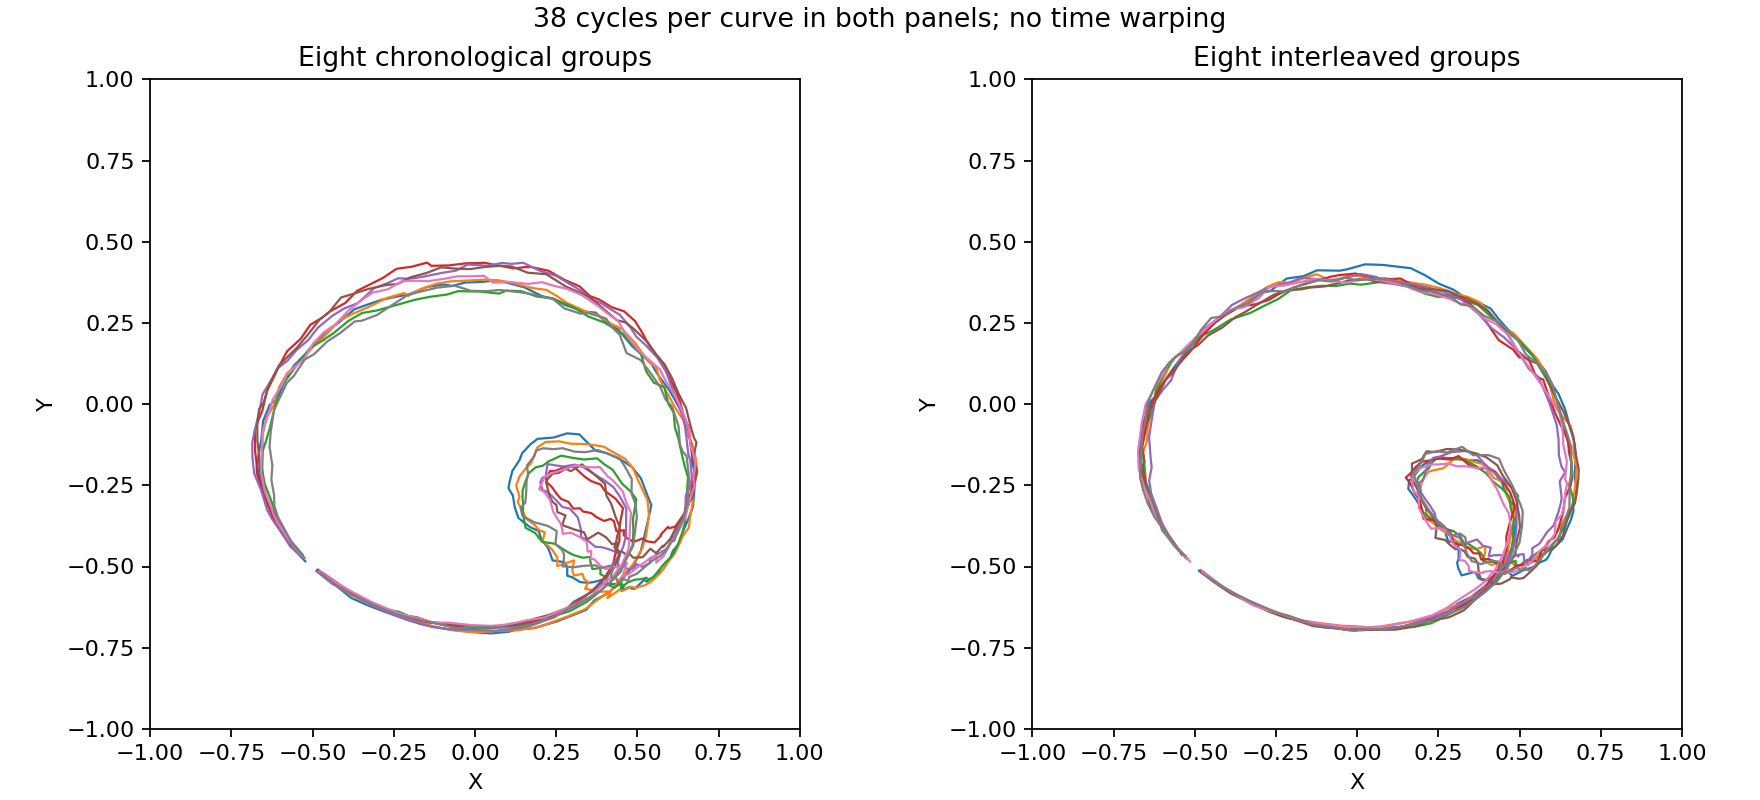

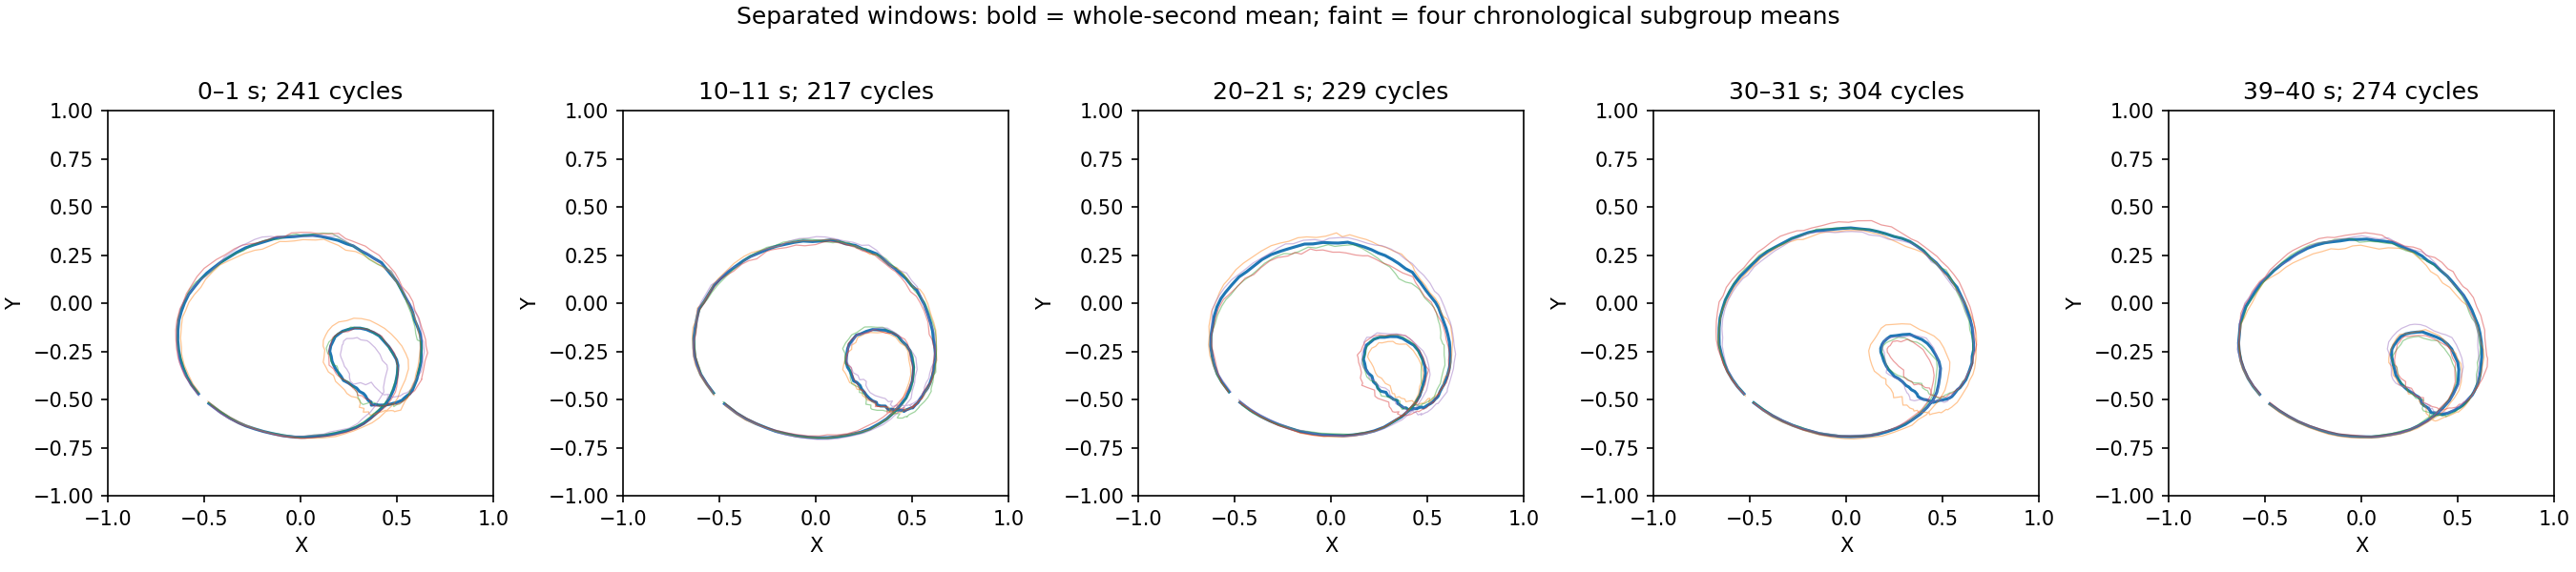

In [3]:
R=OUT
z=np.load(R/'averaged_channels.npz');c=z['channels_per_cycle'];mean=xy(c.mean(axis=0));n=len(c)
groups=np.array_split(np.arange(n),8)
inter=[np.arange(j,n,8) for j in range(8)]
res=dict(chronological_geometric_rms=[geom(xy(c[g].mean(axis=0)),mean) for g in groups],
 interleaved_geometric_rms=[geom(xy(c[g].mean(axis=0)),mean) for g in inter])
# A geometric check of whether the outer loop was accidentally skipped/doubled.
p=guide(raw,41);b=z['interval_bounds'];wind=[]
for a,e in zip(b[:-1],b[1:]):
 q=p[a:e]-[-.3,0];q=np.vstack([q,q[0]])
 t=np.unwrap(np.arctan2(q[:,1],q[:,0]));wind.append(int(np.rint((t[-1]-t[0])/(2*np.pi))))
res['outer_loop_winding_counts']={str(w):int(sum(np.array(wind)==w)) for w in set(wind)}
# Same number of cycles per mean, but chronological vs interleaved groups.
# This distinguishes stable ensemble mean from stable path in each time block.
import matplotlib.pyplot as plt
fig,axs=plt.subplots(1,2,figsize=(11,5),layout='constrained')
for ax,gs,title in [(axs[0],groups,'Eight chronological groups'),(axs[1],inter,'Eight interleaved groups')]:
 for g in gs:
  q=xy(c[g].mean(axis=0));ax.plot(q[:,0],q[:,1],lw=1)
 ax.set(xlim=(-1,1),ylim=(-1,1),aspect='equal',xlabel='X',ylabel='Y',title=title)
fig.suptitle('38 cycles per curve in both panels; no time warping')
fig.savefig(R/'chronological_vs_interleaved.png',dpi=160);plt.close(fig)
# Explore additional separated windows, keeping this same gate and fixed gains.
from nptdms import TdmsFile
res['separated_windows']=[]
fig,axs=plt.subplots(1,5,figsize=(18,4),layout='constrained')
with TdmsFile.open(TDMS_PATH) as f:
 ch=f.groups()[0].channels()
 for ax,start in zip(axs,[0,10,20,30,39]):
  a=round((start-offset)/DT);e=a+round(1/DT)
  rr=np.array([t[a:e] for t in ch],float)[[3,0,1,2]];gg=guide(rr,41);bb=anchors(gg)
  if len(bb)>1:
   cc,_,_=bin_cycles(rr,gg,bb);mm=xy(cc.mean(axis=0))
   ax.plot(mm[:,0],mm[:,1],lw=1.5)
   parts=np.array_split(np.arange(len(cc)),4)
   for ids in parts:
    pp=xy(cc[ids].mean(axis=0));ax.plot(pp[:,0],pp[:,1],lw=.6,alpha=.45)
   res['separated_windows'].append(dict(start_s=start,n_cycles=len(cc),
     geometric_rms_to_30s=geom(mm,mean),quarter_mean_geometric_rms=[geom(xy(cc[ids].mean(axis=0)),mm) for ids in parts]))
   ax.set_title(f'{start}–{start+1} s; {len(cc)} cycles')
  else:ax.set_title(f'{start}–{start+1} s: gate failed')
  ax.set(xlim=(-1,1),ylim=(-1,1),aspect='equal',xlabel='X',ylabel='Y')
fig.suptitle('Separated windows: bold = whole-second mean; faint = four chronological subgroup means')
fig.savefig(R/'separated_windows.png',dpi=150);plt.close(fig)
(R/'extra_metrics.json').write_text(json.dumps(res,indent=2)+'\n');print(json.dumps(res,indent=2))

for name in ['chronological_vs_interleaved.png','separated_windows.png']:
    display(Image(filename=str(OUT/name)))
